<a href="https://colab.research.google.com/github/Sherlysukmadira/DIF62130_A_25_2311532015_SHERLY-SUKMADIRA-PUTRI/blob/main/Prediksi%20Kelolosan%20Beasiswa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# Basic libraries
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization (EDA nanti)
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Preprocessing
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# =========================
# Deep Learning (CNN)
# =========================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:

df = pd.read_excel("BANTUAN PENDIDIKAN.xlsx")

# Lihat 5 data teratas
df.head()


,ID,Nama,IPK_S1,IPK_S2,IPK_S3,Penghasilan_S1,Penghasilan_S2,Penghasilan_S3,Prestasi_S1,Prestasi_S2,...,Organisasi_S1,Organisasi_S2,Organisasi_S3,Tanggungan,Jenis_Kelamin,Domisili,Status_Kampus,Nama_Kampus,Jarak_km,Kelayakan
0,CPB00001,Rani Azhari,3.46,3.73,3.64,2450000,2550000,2650000,1,2,...,Pasif,Pasif,Pasif,5,Perempuan,Kuranji,Swasta,Universitas Baiturrahmah,3.965311,1
1,CPB00002,Hendra Fauzan,3.34,2.49,2.71,3000000,3050000,3050000,3,1,...,Aktif,Aktif,Aktif,5,Laki-laki,Pauh,Negeri,Universitas Sumatera Utara,537.030626,1
2,CPB00003,Erni Santoso,2.13,3.80,2.03,3000000,3100000,3200000,0,2,...,Pasif,Aktif,Aktif,4,Perempuan,Bungus Teluk Kabung,Swasta,Universitas Ekasakti,11.848483,0
3,CPB00004,Hendra Utami,2.41,2.07,3.16,7050000,7200000,7100000,3,3,...,Pasif,Pasif,Aktif,4,Laki-laki,Lubuk Kilangan,Negeri,Universitas Gadjah Mada,1334.455690,1
4,CPB00005,Azmi Bahari,2.40,3.79,2.77,3000000,3100000,3150000,0,3,...,Pasif,Pasif,Pasif,1,Laki-laki,Bungus Teluk Kabung,Negeri,Universitas Gadjah Mada,1334.603420,1


In [ ]:
# Ukuran data
df.shape
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              5000 non-null   object 
 1   Nama            5000 non-null   object 
 2   IPK_S1          5000 non-null   float64
 3   IPK_S2          5000 non-null   float64
 4   IPK_S3          5000 non-null   float64
 5   Penghasilan_S1  5000 non-null   int64  
 6   Penghasilan_S2  5000 non-null   int64  
 7   Penghasilan_S3  5000 non-null   int64  
 8   Prestasi_S1     5000 non-null   int64  
 9   Prestasi_S2     5000 non-null   int64  
 10  Prestasi_S3     5000 non-null   int64  
 11  Organisasi_S1   5000 non-null   object 
 12  Organisasi_S2   5000 non-null   object 
 13  Organisasi_S3   5000 non-null   object 
 14  Tanggungan      5000 non-null   int64  
 15  Jenis_Kelamin   5000 non-null   object 
 16  Domisili        5000 non-null   object 
 17  Status_Kampus   5000 non-null   o

Index(['ID', 'Nama', 'IPK_S1', 'IPK_S2', 'IPK_S3', 'Penghasilan_S1',
       'Penghasilan_S2', 'Penghasilan_S3', 'Prestasi_S1', 'Prestasi_S2',
       'Prestasi_S3', 'Organisasi_S1', 'Organisasi_S2', 'Organisasi_S3',
       'Tanggungan', 'Jenis_Kelamin', 'Domisili', 'Status_Kampus',
       'Nama_Kampus', 'Jarak_km', 'Kelayakan'],
      dtype='object')

In [ ]:
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              5000 non-null   object 
 1   Nama            5000 non-null   object 
 2   IPK_S1          5000 non-null   float64
 3   IPK_S2          5000 non-null   float64
 4   IPK_S3          5000 non-null   float64
 5   Penghasilan_S1  5000 non-null   int64  
 6   Penghasilan_S2  5000 non-null   int64  
 7   Penghasilan_S3  5000 non-null   int64  
 8   Prestasi_S1     5000 non-null   int64  
 9   Prestasi_S2     5000 non-null   int64  
 10  Prestasi_S3     5000 non-null   int64  
 11  Organisasi_S1   5000 non-null   object 
 12  Organisasi_S2   5000 non-null   object 
 13  Organisasi_S3   5000 non-null   object 
 14  Tanggungan      5000 non-null   int64  
 15  Jenis_Kelamin   5000 non-null   object 
 16  Domisili        5000 non-null   object 
 17  Status_Kampus   5000 non-null   o

,ID,Nama,IPK_S1,IPK_S2,IPK_S3,Penghasilan_S1,Penghasilan_S2,Penghasilan_S3,Prestasi_S1,Prestasi_S2,...,Organisasi_S1,Organisasi_S2,Organisasi_S3,Tanggungan,Jenis_Kelamin,Domisili,Status_Kampus,Nama_Kampus,Jarak_km,Kelayakan
count,5000,5000,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,...,5000,5000,5000,5000.000000,5000,5000,5000,5000,5000.000000,5000.000000
unique,5000,4993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2,2,NaN,2,11,2,12,NaN,NaN
top,CPB05000,Putri Wijaya,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Pasif,Aktif,Aktif,NaN,Perempuan,Lubuk Kilangan,Swasta,Universitas Putra Indonesia YPTK,NaN,NaN
freq,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2539,3731,4363,NaN,2502,485,2507,554,NaN,NaN
mean,NaN,NaN,2.996748,2.992026,2.994924,4.594670e+06,4.640670e+06,4.688000e+06,1.502400,1.484000,...,NaN,NaN,NaN,3.519200,NaN,NaN,NaN,NaN,386.626211,0.593800
std,NaN,NaN,0.584013,0.575955,0.576392,2.113282e+06,2.122941e+06,2.142261e+06,1.115456,1.123742,...,NaN,NaN,NaN,1.702766,NaN,NaN,NaN,NaN,548.141103,0.491172
min,NaN,NaN,2.000000,2.000000,2.000000,2.100000e+06,2.100000e+06,2.100000e+06,0.000000,0.000000,...,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.603272,0.000000
25%,NaN,NaN,2.490000,2.490000,2.500000,3.000000e+06,3.050000e+06,3.100000e+06,1.000000,0.000000,...,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,5.768750,0.000000
50%,NaN,NaN,2.990000,2.980000,2.990000,3.950000e+06,3.950000e+06,4.050000e+06,1.000000,1.000000,...,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,11.021350,1.000000
75%,NaN,NaN,3.500000,3.490000,3.490000,5.550000e+06,5.600000e+06,5.650000e+06,3.000000,2.000000,...,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,947.230100,1.000000


In [ ]:
spatial_features = [
    "Tanggungan",
    "Jenis_Kelamin",
    "Domisili",
    "Status_Kampus",
    "Nama_Kampus",
    "Jarak_km"
]

target = "Kelayakan"

df[spatial_features + [target]].head()


,Tanggungan,Jenis_Kelamin,Domisili,Status_Kampus,Nama_Kampus,Jarak_km,Kelayakan
0,5,Perempuan,Kuranji,Swasta,Universitas Baiturrahmah,3.965311,1
1,5,Laki-laki,Pauh,Negeri,Universitas Sumatera Utara,537.030626,1
2,4,Perempuan,Bungus Teluk Kabung,Swasta,Universitas Ekasakti,11.848483,0
3,4,Laki-laki,Lubuk Kilangan,Negeri,Universitas Gadjah Mada,1334.455690,1
4,1,Laki-laki,Bungus Teluk Kabung,Negeri,Universitas Gadjah Mada,1334.603420,1


In [ ]:
df[spatial_features].isnull().sum()


,0
Tanggungan,0
Jenis_Kelamin,0
Domisili,0
Status_Kampus,0
Nama_Kampus,0
Jarak_km,0


In [ ]:
df[target].isnull().sum()


np.int64(0)

In [ ]:
df["Tanggungan"].describe()

,Tanggungan
count,5000.000000
mean,3.519200
std,1.702766
min,1.000000
25%,2.000000
50%,4.000000
75%,5.000000
max,6.000000


In [ ]:
df["Jarak_km"].describe()

,Jarak_km
count,5000.000000
mean,386.626211
std,548.141103
min,0.603272
25%,5.768750
50%,11.021350
75%,947.230100
max,1509.777518


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
for col in spatial_features:
    if df[col].dtype == "object":
        print(f"\n{col}")
        print(df[col].unique())



Jenis_Kelamin
['Perempuan' 'Laki-laki']

Domisili
['Kuranji' 'Pauh' 'Bungus Teluk Kabung' 'Lubuk Kilangan' 'Padang Timur'
 'Koto Tangah' 'Nanggalo' 'Lubuk Begalung' 'Padang Barat' 'Padang Utara'
 'Padang Selatan']

Status_Kampus
['Swasta' 'Negeri']

Nama_Kampus
['Universitas Baiturrahmah' 'Universitas Sumatera Utara'
 'Universitas Ekasakti' 'Universitas Gadjah Mada'
 'Universitas Negeri Padang' 'Institut Pertanian Bogor'
 'Universitas Andalas' 'Universitas Putra Indonesia YPTK'
 'Institut Teknologi Padang' 'Universitas Bung Hatta'
 'Institut Teknologi Bandung' 'Universitas Indonesia']


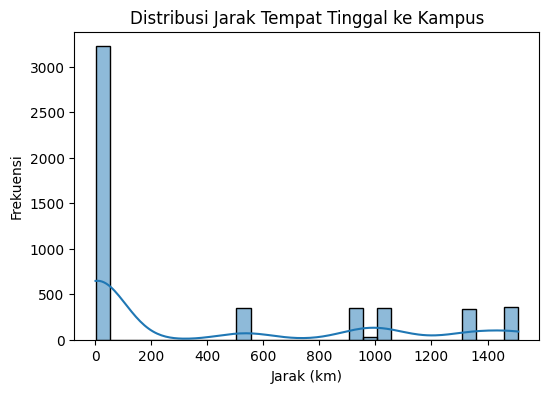

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Jarak_km"], bins=30, kde=True)
plt.title("Distribusi Jarak Tempat Tinggal ke Kampus")
plt.xlabel("Jarak (km)")
plt.ylabel("Frekuensi")
plt.show()


Dominan mahasiswa memiliki domisili dekat dengan kampus

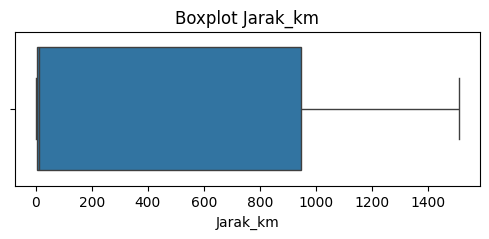

In [ ]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df["Jarak_km"])
plt.title("Boxplot Jarak_km")
plt.show()


Tidak terdapat outlier


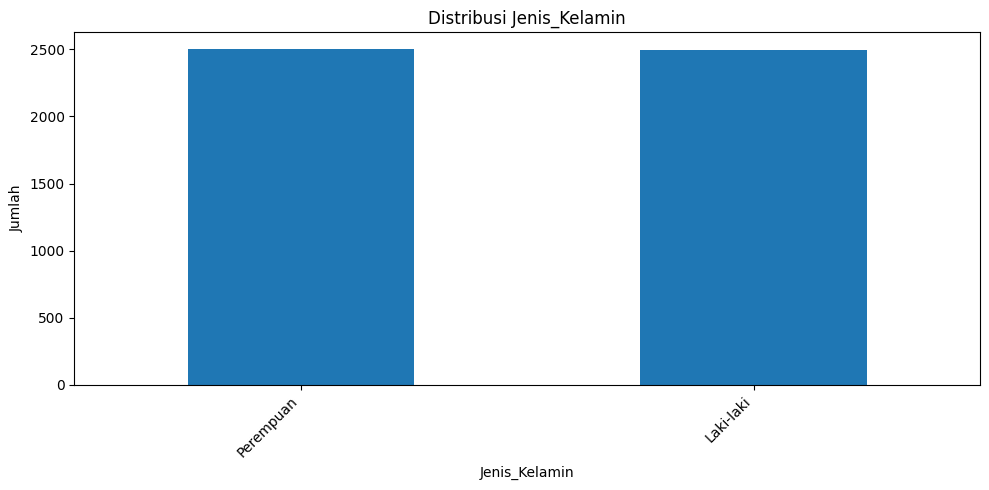

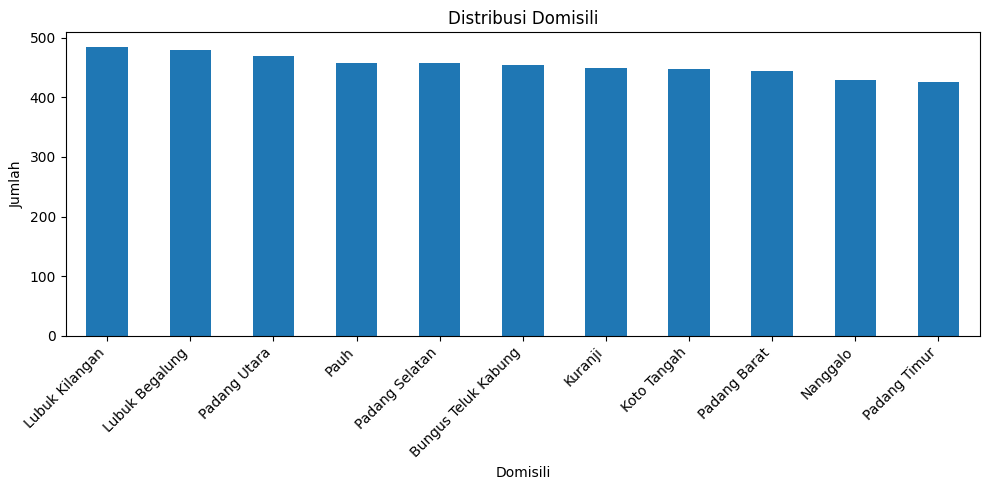

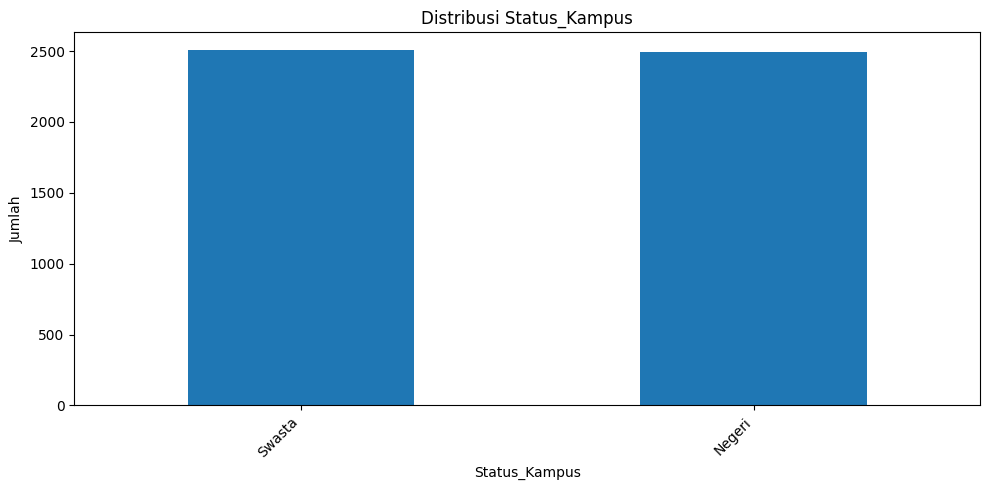

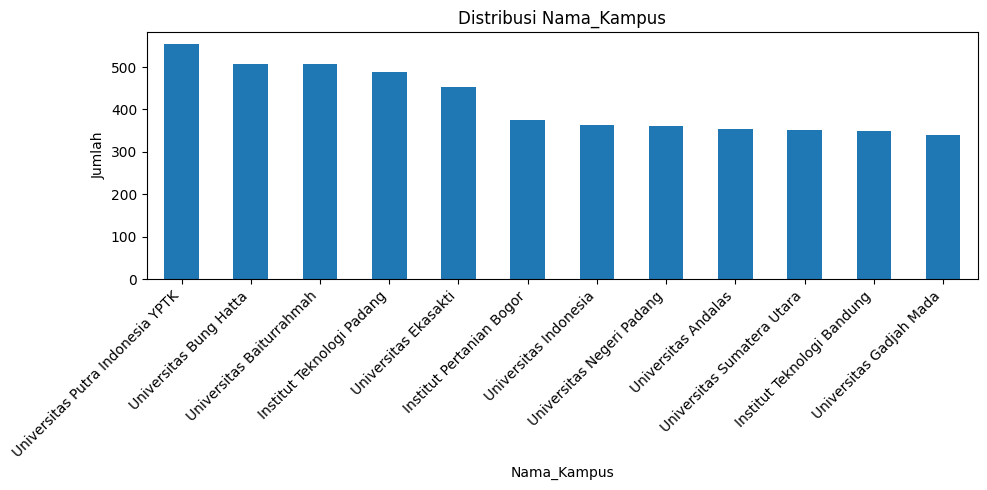

In [ ]:
for col in spatial_features:
    if df[col].dtype == "object":
        counts = df[col].value_counts().sort_values(ascending=False)

        plt.figure(figsize=(10,5))
        counts.plot(kind="bar")
        plt.title(f"Distribusi {col}")
        plt.ylabel("Jumlah")
        plt.xlabel(col)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


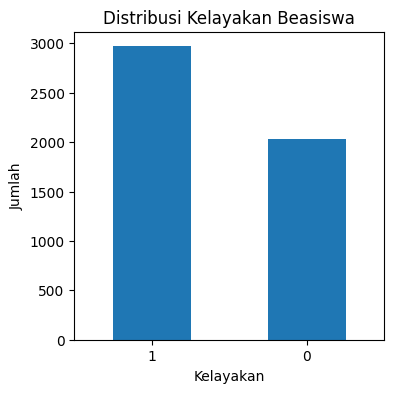

In [ ]:
#distirbusi target dan keseluruhan data
plt.figure(figsize=(4,4))
df[target].value_counts().plot(kind="bar")
plt.title("Distribusi Kelayakan Beasiswa")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()


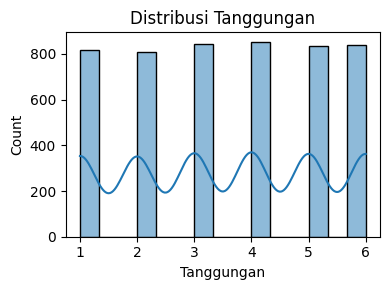

In [ ]:
num_cols = ["Tanggungan"]

for col in num_cols:
    plt.figure(figsize=(4,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi {col}")
    plt.tight_layout()
    plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil hanya kolom numerik
df_numeric = df.select_dtypes(include=["int64", "float64"])

print(df_numeric.columns)


Index(['IPK_S1', 'IPK_S2', 'IPK_S3', 'Penghasilan_S1', 'Penghasilan_S2',
       'Penghasilan_S3', 'Prestasi_S1', 'Prestasi_S2', 'Prestasi_S3',
       'Tanggungan', 'Jarak_km', 'Kelayakan'],
      dtype='object')


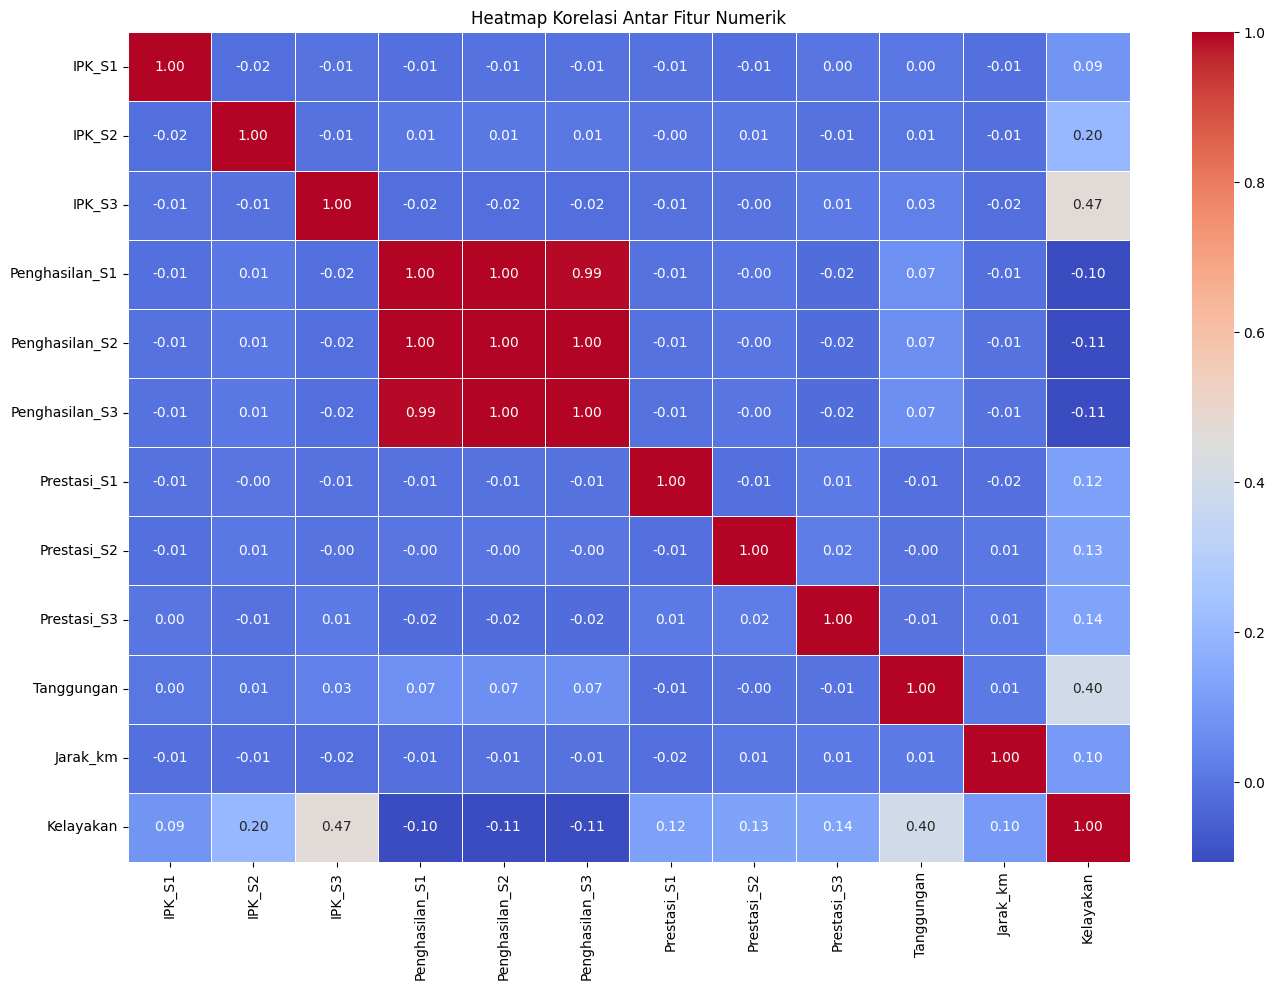

In [ ]:
#
corr_matrix = df_numeric.corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Heatmap Korelasi Antar Fitur Numerik")
plt.tight_layout()
plt.show()


ENCODING FITUR KATEGORIKAL


In [ ]:
X = df[spatial_features]
y = df[target]

In [ ]:
#Identifikasi kolom kategorikal
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical:", cat_cols)
print("Numerical:", num_cols)


Categorical: Index(['Jenis_Kelamin', 'Domisili', 'Status_Kampus', 'Nama_Kampus'], dtype='object')
Numerical: Index(['Tanggungan', 'Jarak_km'], dtype='object')


In [ ]:
#Label encoding
#Label Encoding digunakan untuk mengonversi fitur kategorikal menjadi representasi numerik agar dapat diproses oleh CNN.
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le


/tmp/ipython-input-3417503797.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))
/tmp/ipython-input-3417503797.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))
/tmp/ipython-input-3417503797.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

In [ ]:
#Normalisasi fitur numerik
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


/tmp/ipython-input-3009083587.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[num_cols] = scaler.fit_transform(X[num_cols])


In [ ]:
#Bentuk input untuk CNN spasial
import numpy as np

X_cnn = np.expand_dims(X.values, axis=2)

print(X_cnn.shape)


(5000, 6, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
#Atasi imbalance data
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)


{0: np.float64(1.2307692307692308), 1: np.float64(0.8421052631578947)}


In [ ]:
print(X_train.shape)
print(y_train.shape)


(4000, 6, 1)
(4000,)


Data kategorikal dikonversi menggunakan label encoding, sedangkan fitur numerik dinormalisasi menggunakan Min-Max Scaling. Selanjutnya, data dibentuk ulang menjadi format tiga dimensi agar dapat diproses oleh Convolutional Neural Network sebagai representasi spasial fitur.

BANGUN MODEL CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(32, 1, activation="relu", input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv1D(64, 1, activation="relu"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 32)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 64)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,161 (235.00 KB)

 Trainable params: 59,969 (234.25 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6093 - auc: 0.6332 - loss: 0.6751 - precision: 0.6957 - recall: 0.6264 - val_accuracy: 0.6012 - val_auc: 0.7304 - val_loss: 0.6641 - val_precision: 0.7234 - val_recall: 0.5107
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6480 - auc: 0.7023 - loss: 0.6320 - precision: 0.7391 - recall: 0.6401 - val_accuracy: 0.6775 - val_auc: 0.7387 - val_loss: 0.6280 - val_precision: 0.7600 - val_recall: 0.6524
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6573 - auc: 0.6954 - loss: 0.6331 - precision: 0.7155 - recall: 0.6966 - val_accuracy: 0.6888 - val_auc: 0.7481 - val_loss: 0.6071 - val_precision: 0.6709 - val_recall: 0.9142
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6694 - auc: 0.7006 - loss: 0.6247 - precision: 0.7272 - recall: 0.7299 - val_accuracy: 0.6787 - val_auc: 0.7494 - val_loss: 0.5967 - val_precision: 0.6630 - val_recall: 0.9120
Epoch 5/100
200/200 ━━━━━━━

In [ ]:
y_pred = (model.predict(X_test) > 0.4).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


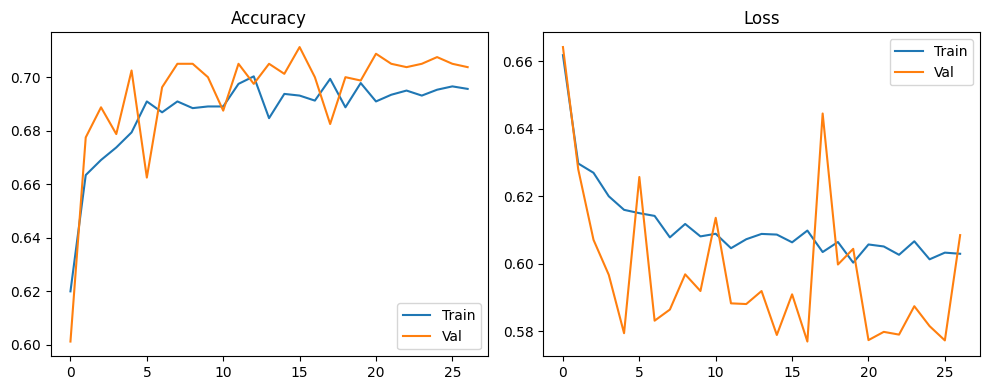

In [ ]:
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()



EVALUASI MODEL

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.63      0.61      0.62       406
           1       0.74      0.75      0.75       594

    accuracy                           0.69      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.69      0.69      0.69      1000



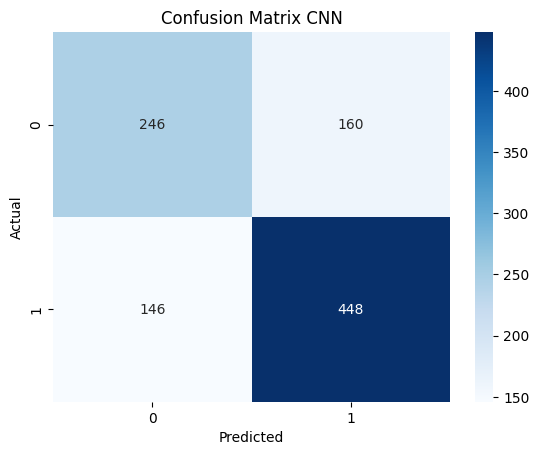

In [ ]:
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


CNN + LSTM

In [ ]:
# REUSE hasil CNN baseline
X_spatial = X.copy().to_numpy()

# reshape untuk CNN
X_spatial = X_spatial.reshape(
    X_spatial.shape[0],
    X_spatial.shape[1],
    1
)


In [ ]:
temporal_features = [
    ["IPK_S1", "Penghasilan_S1", "Prestasi_S1", "Organisasi_S1"],
    ["IPK_S2", "Penghasilan_S2", "Prestasi_S2", "Organisasi_S2"],
    ["IPK_S3", "Penghasilan_S3", "Prestasi_S3", "Organisasi_S3"]
]

In [ ]:
temporal_cat_cols = [
    "Prestasi_S1", "Organisasi_S1",
    "Prestasi_S2", "Organisasi_S2",
    "Prestasi_S3", "Organisasi_S3"
]

In [ ]:
from sklearn.preprocessing import LabelEncoder

temporal_encoders = {}

for col in temporal_cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    temporal_encoders[col] = le

In [ ]:
for col in temporal_cat_cols:
    print(col, df[col].unique())


Prestasi_S1 [1 3 0 2]
Organisasi_S1 [1 0]
Prestasi_S2 [2 1 3 0]
Organisasi_S2 [1 0]
Prestasi_S3 [3 0 2 1]
Organisasi_S3 [1 0]


In [ ]:
for col in temporal_cat_cols:
    print(col, df[col].unique())


Prestasi_S1 [1 3 0 2]
Organisasi_S1 [1 0]
Prestasi_S2 [2 1 3 0]
Organisasi_S2 [1 0]
Prestasi_S3 [3 0 2 1]
Organisasi_S3 [1 0]


In [ ]:
from sklearn.preprocessing import MinMaxScaler

temporal_num_cols = [
    "IPK_S1", "Penghasilan_S1",
    "IPK_S2", "Penghasilan_S2",
    "IPK_S3", "Penghasilan_S3"
]

scaler_temporal = MinMaxScaler()
df[temporal_num_cols] = scaler_temporal.fit_transform(df[temporal_num_cols])


In [ ]:
import numpy as np

X_temporal = []

for i in range(len(df)):
    sequence = []
    for semester in temporal_features:
        sequence.append(df.loc[i, semester].values.astype(float))
    X_temporal.append(sequence)

X_temporal = np.array(X_temporal, dtype=np.float32)

print("X_temporal shape:", X_temporal.shape)
print("Contoh data:", X_temporal[0])


X_temporal shape: (5000, 3, 4)
Contoh data: [[0.73       0.03535353 1.         1.        ]
 [0.865      0.04545455 2.         1.        ]
 [0.82       0.05555556 3.         1.        ]]


In [ ]:
from sklearn.model_selection import train_test_split

X_spatial_train, X_spatial_test, \
X_temporal_train, X_temporal_test, \
y_train, y_test = train_test_split(
    X_spatial,
    X_temporal,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(1.2307692307692308), 1: np.float64(0.8421052631578947)}


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Flatten,
    LSTM, Dense, Dropout, BatchNormalization, Concatenate
)
from tensorflow.keras.models import Model


In [ ]:
spatial_input = Input(shape=(X_spatial.shape[1], 1), name="Spatial_Input")

cnn = Conv1D(32, 1, activation="relu")(spatial_input)
cnn = BatchNormalization()(cnn)
cnn = MaxPooling1D(2)(cnn)

cnn = Conv1D(64, 1, activation="relu")(cnn)
cnn = BatchNormalization()(cnn)

cnn = Flatten()(cnn)


In [ ]:
temporal_input = Input(shape=(X_temporal.shape[1], X_temporal.shape[2]), name="Temporal_Input")

lstm = LSTM(64, return_sequences=False)(temporal_input)


In [ ]:
combined = Concatenate()([cnn, lstm])


In [ ]:
fc = Dense(128, activation="relu")(combined)
fc = Dropout(0.3)(fc)

fc = Dense(64, activation="relu")(fc)
output = Dense(1, activation="sigmoid")(fc)

model_hybrid = Model(
    inputs=[spatial_input, temporal_input],
    outputs=output
)


In [ ]:
model_hybrid.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model_hybrid.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Spatial_Input       │ (None, 6, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 6, 32)     │         64 │ Spatial_Input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 32)     │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 3, 32)     │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 3, 64)     │      2,112 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 64)     │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Temporal_Input      │ (None, 3, 4)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 192)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     17,664 │ Temporal_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,441 (240.00 KB)

 Trainable params: 61,249 (239.25 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model_hybrid.fit(
    [X_spatial_train, X_temporal_train],
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5356 - auc: 0.5552 - loss: 0.7101 - precision: 0.6342 - recall: 0.5257 - val_accuracy: 0.6075 - val_auc: 0.7144 - val_loss: 0.6375 - val_precision: 0.6005 - val_recall: 0.9742
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6794 - auc: 0.7485 - loss: 0.5925 - precision: 0.7573 - recall: 0.6772 - val_accuracy: 0.6825 - val_auc: 0.7755 - val_loss: 0.5854 - val_precision: 0.6667 - val_recall: 0.9099
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7478 - auc: 0.8263 - loss: 0.5137 - precision: 0.8131 - recall: 0.7515 - val_accuracy: 0.7250 - val_auc: 0.8216 - val_loss: 0.5506 - val_precision: 0.6997 - val_recall: 0.9249
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7852 - auc: 0.8600 - loss: 0.4687 - precision: 0.8303 - recall: 0.8015 - val_accuracy: 0.7887 - val_auc: 0.8586 - val_loss: 0.4535 - val_precision: 0.8012 - val_recall: 0.8476
Epoch 5/100
200/200 ━━━━

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
              precision    recall  f1-score   support

           0       0.84      0.79      0.81       406
           1       0.86      0.90      0.88       594

    accuracy                           0.85      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.85      0.85      0.85      1000



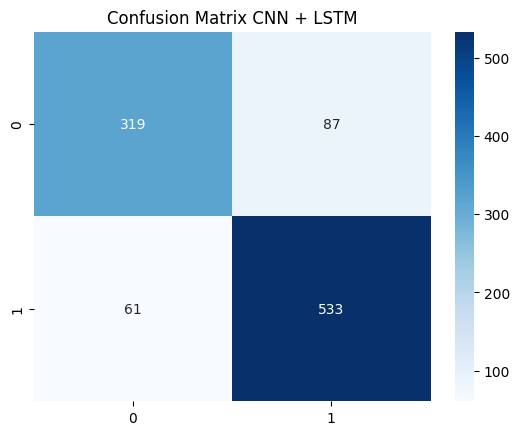

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model_hybrid.predict([X_spatial_test, X_temporal_test]) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix CNN + LSTM")
plt.show()


In [ ]:
# --- OPTIMASI PREPROCESSING (GANTIKAN LOGIKA LAMA) ---
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. Load Ulang (untuk memastikan data fresh)
df = pd.read_excel("BANTUAN PENDIDIKAN.xlsx")

# 2. Proses Fitur Spasial (Gunakan One-Hot Encoding)
# Kita hilangkan ID, Nama, dan Nama_Kampus agar model fokus pada fitur ekonomi & akademik
spatial_raw = df[["Tanggungan", "Jenis_Kelamin", "Domisili", "Status_Kampus", "Jarak_km"]]
X_spatial_encoded = pd.get_dummies(spatial_raw, columns=["Jenis_Kelamin", "Domisili", "Status_Kampus"])

# Scaling Spasial
scaler_spatial = StandardScaler()
X_spatial_final = scaler_spatial.fit_transform(X_spatial_encoded)
X_spatial_final = X_spatial_final.reshape(X_spatial_final.shape[0], X_spatial_final.shape[1], 1)

# 3. Proses Fitur Temporal (IPK, Penghasilan, Prestasi, Organisasi)
# Mapping Organisasi & Prestasi jika masih teks
org_map = {'Aktif': 1, 'Pasif': 0}
for i in range(1, 4):
    df[f'Organisasi_S{i}'] = df[f'Organisasi_S{i}'].map(org_map)
    # Jika Prestasi adalah teks, lakukan mapping serupa di sini

# Scaling angka temporal (IPK & Penghasilan)
temporal_num_cols = ["IPK_S1", "Penghasilan_S1", "IPK_S2", "Penghasilan_S2", "IPK_S3", "Penghasilan_S3"]
scaler_temp = StandardScaler()
df[temporal_num_cols] = scaler_temp.fit_transform(df[temporal_num_cols])

# Bentuk Sequence untuk LSTM (3 Semester)
X_temporal_list = []
for i in range(len(df)):
    seq = [
        df.loc[i, ["IPK_S1", "Penghasilan_S1", "Prestasi_S1", "Organisasi_S1"]].values,
        df.loc[i, ["IPK_S2", "Penghasilan_S2", "Prestasi_S2", "Organisasi_S2"]].values,
        df.loc[i, ["IPK_S3", "Penghasilan_S3", "Prestasi_S3", "Organisasi_S3"]].values
    ]
    X_temporal_list.append(seq)
X_temporal_final = np.array(X_temporal_list, dtype='float32')

# Target
y = df['Kelayakan'].values

# Split Data (Pastikan semua seimbang)
from sklearn.model_selection import train_test_split
X_sp_train, X_sp_test, X_temp_train, X_temp_test, y_train, y_test = train_test_split(
    X_spatial_final, X_temporal_final, y, test_size=0.2, random_state=42, stratify=y
)

print("Data siap! Spasial:", X_sp_train.shape, "Temporal:", X_temp_train.shape)

Data siap! Spasial: (4000, 17, 1) Temporal: (4000, 3, 4)


In [ ]:
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Flatten, LSTM, Bidirectional, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Jalur Spasial (CNN)
input_sp = Input(shape=(X_sp_train.shape[1], 1), name="Spatial_Input")
cnn = Conv1D(64, kernel_size=3, padding='same', activation='relu')(input_sp)
cnn = BatchNormalization()(cnn)
cnn = Conv1D(128, kernel_size=3, padding='same', activation='relu')(cnn)
cnn = BatchNormalization()(cnn)
cnn = Flatten()(cnn)

# 2. Jalur Temporal (Bidirectional LSTM)
input_temp = Input(shape=(3, 4), name="Temporal_Input")
lstm = Bidirectional(LSTM(128, return_sequences=True))(input_temp)
lstm = LSTM(64)(lstm)
lstm = Dropout(0.3)(lstm)

# 3. Penggabungan (Fusion)
merged = Concatenate()([cnn, lstm])
dense = Dense(128, activation='relu')(merged)
dense = Dropout(0.4)(dense)
dense = Dense(64, activation='relu')(dense)
output = Dense(1, activation='sigmoid')(dense)

# Bangun Model
model_optimized = Model(inputs=[input_sp, input_temp], outputs=output)

# Optimizer dengan Learning Rate yang fleksibel
model_optimized.compile(optimizer=Adam(learning_rate=0.001),
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

model_optimized.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Spatial_Input       │ (None, 17, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 17, 64)    │        256 │ Spatial_Input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Temporal_Input      │ (None, 3, 4)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 17, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 3, 256)    │    136,192 │ Temporal_Input[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 128)   │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     82,176 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2176)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2240)      │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │    286,848 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         65 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 539,265 (2.06 MB)

 Trainable params: 538,881 (2.06 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# Callback untuk mencegah overfitting & meningkatkan akurasi
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

history = model_optimized.fit(
    [X_sp_train, X_temp_train], y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6437 - loss: 0.7263 - val_accuracy: 0.7925 - val_loss: 0.5600 - learning_rate: 0.0010
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8378 - loss: 0.3670 - val_accuracy: 0.8200 - val_loss: 0.4885 - learning_rate: 0.0010
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8679 - loss: 0.3027 - val_accuracy: 0.8500 - val_loss: 0.3485 - learning_rate: 0.0010
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8783 - loss: 0.2829 - val_accuracy: 0.8775 - val_loss: 0.2719 - learning_rate: 0.0010
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8989 - loss: 0.2418 - val_accuracy: 0.9050 - val_loss: 0.2205 - learning_rate: 0.0010
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9017 - loss: 0.2260 - val_accuracy: 0.8875 - val_loss: 0.2736 - learning_rate: 0.0010
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9145 - loss: 0.

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
HASIL EVALUASI MODEL OPTIMIZED:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       406
           1       0.96      0.93      0.94       594

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



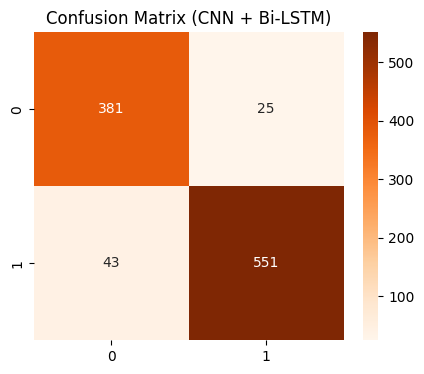

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model_optimized.predict([X_sp_test, X_temp_test]) > 0.5).astype(int)

print("HASIL EVALUASI MODEL OPTIMIZED:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix (CNN + Bi-LSTM)")
plt.show()

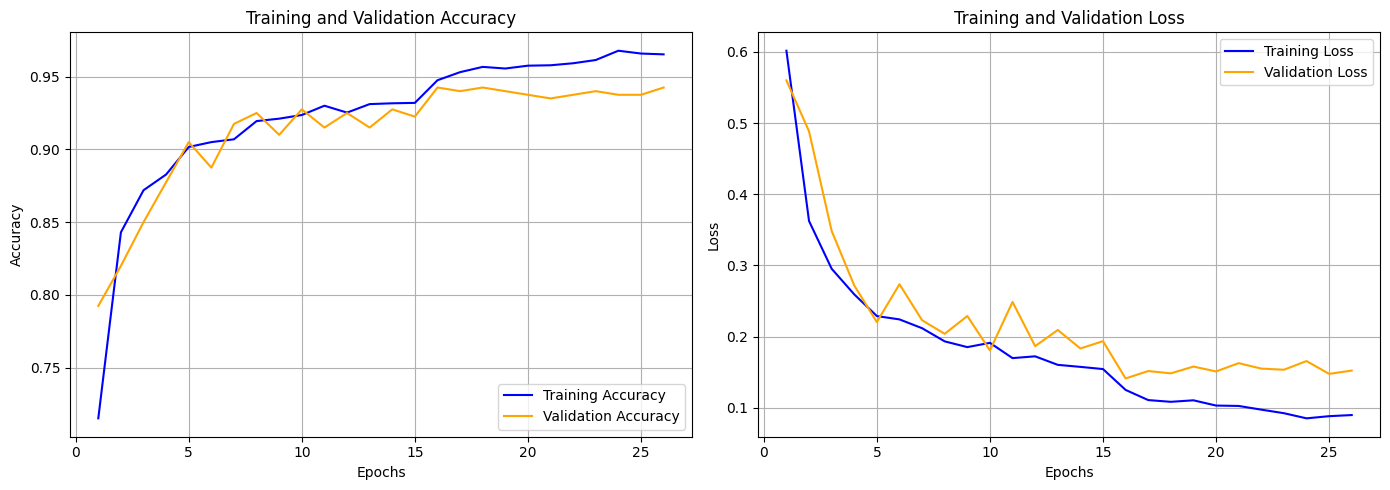

In [ ]:
# === VISUALISASI RIWAYAT PELATIHAN (LEARNING CURVE) ===
import matplotlib.pyplot as plt

# Mengambil data dari variabel 'history' (hasil training)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# 1. Plot Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Plot Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()